# 基础代码

In [12]:
import deepquantum as dq
import numpy as np
import torch

squeezing = [1] * 6
unitary = np.eye(6)
gbs = dq.photonic.GaussianBosonSampling(nmode=6, squeezing=squeezing, unitary=unitary)
gbs()
gbs.draw()  # 画出采样线路

PNRD（光子数可分辨探测器）： 它具有极高的灵敏度和分辨率，能够精确地告诉你：“现在打过来的是 0 个、1 个、2 个还是 n 个光子”。它克服了饱和效应，能输出具体的光子计数。

In [14]:
gbs.detector = 'pnrd'
result = gbs.measure(shots=1024, mcmc=True)
print(result)

Using MCMC method to sample the final states!


chain 5: 100%|███████████████████████████████| 207/207 [00:00<00:00, 556.44it/s]

{|002012>: 204, |112220>: 204, |201210>: 204, |220011>: 204, |200220>: 208}


阈值探测器

In [60]:
gbs.detector = 'threshold'
result = gbs.measure(shots=1024, mcmc=True)
print(result)

Using MCMC method to sample the final states!


chain 5: 100%|████████████████████████████| 207/207 [00:00<00:00, 158898.41it/s]

{|001000>: 33, |010111>: 6, |011001>: 14, |011100>: 12, |111000>: 9, |110010>: 12, |100000>: 57, |111110>: 6, |101010>: 27, |010101>: 19, |110000>: 30, |100001>: 27, |000100>: 48, |000110>: 17, |000111>: 20, |101000>: 34, |010100>: 35, |111100>: 3, |001101>: 16, |101101>: 10, |001001>: 28, |000011>: 31, |000001>: 30, |100011>: 6, |001011>: 12, |000000>: 32, |100100>: 22, |010010>: 28, |000010>: 57, |100010>: 13, |001100>: 29, |001010>: 29, |100101>: 14, |100111>: 4, |010000>: 14, |110110>: 4, |101011>: 9, |011010>: 9, |001111>: 13, |111010>: 4, |110100>: 7, |000101>: 14, |011111>: 7, |110111>: 6, |110001>: 13, |111001>: 6, |101001>: 12, |110011>: 1, |100110>: 8, |010001>: 20, |011000>: 8, |110101>: 10, |010110>: 15, |011011>: 10, |010011>: 8, |011101>: 9, |111011>: 3, |101110>: 4, |111111>: 1, |011110>: 4, |001110>: 13, |101100>: 16, |111101>: 3, |101111>: 3}


# 图

生成的邻接矩阵：
[[0 1 0 1 0 0]
 [1 0 0 0 1 1]
 [0 0 0 1 0 0]
 [1 0 1 0 0 0]
 [0 1 0 0 0 1]
 [0 1 0 0 1 0]]
----------------------------------------


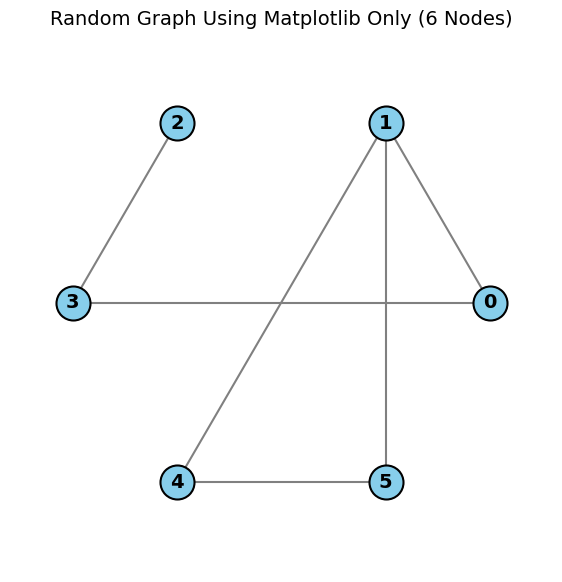

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 参数设置
num_nodes = 6  # 节点数量
probability = 0.5  # 连边概率

# 2. 随机生成邻接矩阵 (0表示无边，1表示有边)
# 这里生成一个无向图的对称矩阵，且对角线为0（无自环）
adj_matrix = np.random.choice(
    [0, 1], size=(num_nodes, num_nodes), p=[1 - probability, probability]
)
adj_matrix = np.triu(adj_matrix, k=1)  # 只保留上三角
adj_matrix = adj_matrix + adj_matrix.T  # 镜像到下三角，形成对称矩阵

print("生成的邻接矩阵：")
print(adj_matrix)
print("-" * 40)

# 3. 手动计算节点的坐标 (让节点均匀分布在一个圆圈上)
# 利用极坐标公式：x = cos(θ), y = sin(θ)
angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
x_coords = np.cos(angles)
y_coords = np.sin(angles)

# 4. 开始绘图
fig, ax = plt.subplots(figsize=(7, 7))

# 绘制边 (遍历邻接矩阵的上三角，避免重复画线)
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        if adj_matrix[i, j] == 1:
            # 连接节点 i 和节点 j 的线
            ax.plot(
                [x_coords[i], x_coords[j]],
                [y_coords[i], y_coords[j]],
                color="gray",
                linestyle="-",
                linewidth=1.5,
                zorder=1,  # 让线处于底层
            )

# 绘制节点
ax.scatter(
    x_coords,
    y_coords,
    s=600,
    color="skyblue",
    edgecolors="black",
    linewidths=1.5,
    zorder=2,  # 让点处于表层
)

# 绘制节点标签（数字编号）
for i in range(num_nodes):
    ax.text(
        x_coords[i],
        y_coords[i],
        str(i),
        color="black",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=3,  # 让文字处于最表层
    )

# 美化界面，隐藏坐标轴和边框
ax.axis("off")
# 稍微扩大一点坐标轴范围，防止边缘的节点显示不全
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
plt.title(f"Random Graph Using Matplotlib Only ({num_nodes} Nodes)", fontsize=14)

# 5. 显示图形
plt.show()

In [62]:
adj_matrix

array([[0, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 1, 1],
       [0, 0, 0, 1, 0, 0],
       [1, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 1],
       [0, 1, 0, 0, 1, 0]])

# 编码

np.allclose 是 NumPy 中用于比较两个数组是否“近似相等”的核心函数。它在数值计算中非常重要，因为由于浮点数精度问题，直接使用 == 比较两个浮点数数组几乎总会返回 False。

In [63]:
def encode_graph_to_unitary(A, c_ratio=0.3):
    """
    Encodes a given adjacency matrix into a unitary matrix suitable for Gaussian Boson Sampling (GBS).

    Args:
        A (np.ndarray):     The adjacency matrix of the graph.
        c_ratio (float):    The ratio of the scaling factor c to its maximum theoretical upper bound. 
                            Must be within the range (0, 1). Defaults to 0.9 for safety.

    Returns:
        T (np.ndarray):     The linear optical network matrix (a unitary matrix).
        r (np.ndarray):     A list of physical photon squeezing coefficients for each mode.
    """

    # Ensure the adjacency matrix is symmetric and has zeros on the diagonal
    assert np.allclose(A, A.T), "Adjacency matrix must be symmetric"
    assert np.all(np.diag(A) == 0), "Adjacency matrix must have zeros on the diagonal"

    W = A @ A.conj().T

    d, U = np.linalg.eigh(W)
    d = np.maximum(d, 0) 

    B = U.conj().T @ A @ U.conj()

    B_diag = np.diag(B)

    phi = np.angle(B_diag)/2.0

    phase = np.diag(np.exp(1j * phi))
    T = U @ phase @ U.conj().T

    sqrt_d = np.sqrt(d)
    max_sqrt_d = np.max(sqrt_d)

    if max_sqrt_d > 1e-9:
        c_max = 1.0 / max_sqrt_d
        c = c_ratio * c_max
    else:
        c = 1.0

    tanh_r = c * sqrt_d
    tanh_r = np.clip(tanh_r, 0, 0.999999)
    r = np.arctanh(tanh_r)
    r = torch.tensor(r, dtype=torch.float32)
    
    return T, r

In [64]:
unitary, squeezing = encode_graph_to_unitary(adj_matrix)

In [65]:
unitary

array([[ 0.670256  +0.329744j  ,  0.31290821-0.31290821j,
        -0.15342022+0.15342022j,  0.27226303-0.27226303j,
        -0.11277504+0.11277504j, -0.11277504+0.11277504j],
       [ 0.31290821-0.31290821j,  0.4173537 +0.5826463j ,
        -0.14012726+0.14012726j,  0.02735222-0.02735222j,
         0.24987421-0.24987421j,  0.24987421-0.24987421j],
       [-0.15342022+0.15342022j, -0.14012726+0.14012726j,
         0.64290378+0.35709622j,  0.4123903 -0.4123903j ,
         0.09038622-0.09038622j,  0.09038622-0.09038622j],
       [ 0.27226303-0.27226303j,  0.02735222-0.02735222j,
         0.4123903 -0.4123903j ,  0.48948356+0.51051644j,
        -0.04974104+0.04974104j, -0.04974104+0.04974104j],
       [-0.11277504+0.11277504j,  0.24987421-0.24987421j,
         0.09038622-0.09038622j, -0.04974104+0.04974104j,
         0.39000148+0.60999852j,  0.39000148-0.39000148j],
       [-0.11277504+0.11277504j,  0.24987421-0.24987421j,
         0.09038622-0.09038622j, -0.04974104+0.04974104j,
         

In [66]:
squeezing

tensor([0.0250, 0.1355, 0.1355, 0.1852, 0.2436, 0.3095])

# 实验

In [67]:
gbs = dq.photonic.GaussianBosonSampling(nmode=6, squeezing=squeezing, unitary=unitary)
gbs()
gbs.draw()  # 画出采样线路

In [68]:
gbs.detector = 'pnrd'
result = gbs.measure(shots=1024*2, mcmc=True)
print(result)

Using MCMC method to sample the final states!


chain 5: 100%|██████████████████████████████| 411/411 [00:00<00:00, 8431.11it/s]

{|000000>: 1570, |022220>: 2, |111012>: 10, |200121>: 19, |022002>: 2, |110112>: 8, |011112>: 12, |110002>: 1, |001100>: 207, |000011>: 19, |001012>: 13, |110110>: 7, |101101>: 14, |101110>: 4, |020002>: 20, |000121>: 20, |020000>: 13, |110000>: 14, |010010>: 52, |011002>: 11, |200222>: 1, |120201>: 2, |211000>: 1, |110022>: 16, |200002>: 5, |020011>: 1, |000022>: 4}


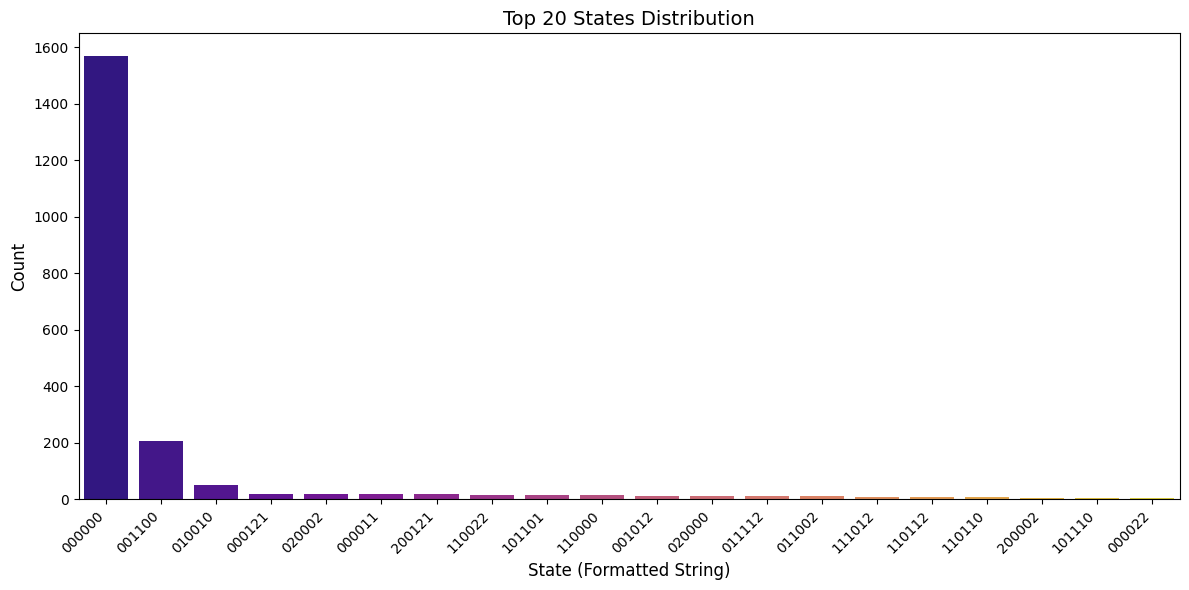

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 假设这是你的原始字典对象
# result = {...} 

# 2. 格式化键
formatted_data = {str(k).strip('|>'): v for k, v in result.items()}

# 3. 装载进 DataFrame 并排序
df = pd.DataFrame(list(formatted_data.items()), columns=['State', 'Count'])
df = df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# 4. 画图（已修复 FutureWarning）
plt.figure(figsize=(12, 6))

sns.barplot(
    x='State', 
    y='Count', 
    data=df.head(20), 
    palette='plasma', 
    hue='State', 
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 20 States Distribution', fontsize=14)
plt.xlabel('State (Formatted String)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

plt.show()

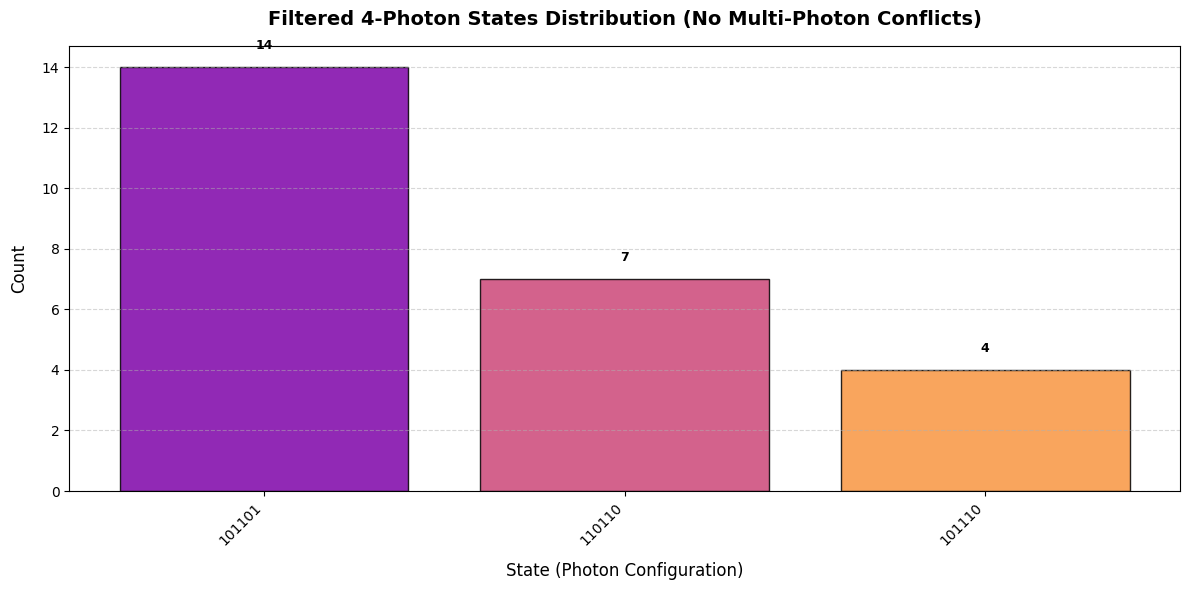

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你的采样结果存在名为 result 的字典中
# result = { fock_state_obj1: count1, fock_state_obj2: count2, ... }

filtered_result = {}

for fock_state_obj, count in result.items():
    # 1. 直接获取光子数列表，例如 [0, 0, 1, 1, 2, 0]
    photon_list = fock_state_obj.state.tolist()
    
    # 2. 检查是否有冲突：只要有任何一个通道的光子数大于 1，就属于冲突情况，跳过
    if any(x > 1 for x in photon_list):
        continue
        
    # 3. 检查是否是四光子事件：所有通道的光子数总和必须严格等于 4
    if sum(photon_list) == 4:
        # 获取该状态的字符串表示作为画图的标签，例如 "011110"
        # 如果你的 __repr__ 带指针符号，可以用 str(fock_state_obj).replace('|','').replace('>','')
        state_label = "".join(map(str, photon_list))
        filtered_result[state_label] = count

# 4. 按出现频次（Count）从大到小排序
sorted_filtered = sorted(filtered_result.items(), key=lambda x: x[1], reverse=True)

# 如果过滤后有数据，开始绘图
if sorted_filtered:
    states = [item[0] for item in sorted_filtered]
    counts = [item[1] for item in sorted_filtered]
    
    # 5. 绘制条形图
    plt.figure(figsize=(12, 6), dpi=100)
    # 使用渐变色让图表更美观
    colors = sns.color_palette("plasma", len(states))
    
    bars = plt.bar(states, counts, color=colors, edgecolor='black', alpha=0.85)
    
    # 在柱状图上方标注具体数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
                 
    plt.title("Filtered 4-Photon States Distribution (No Multi-Photon Conflicts)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("State (Photon Configuration)", fontsize=12, labelpad=10)
    plt.ylabel("Count", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("当前采样结果中没有找到‘无冲突的严格四光子’状态！请检查样本量或实验能量设置。")

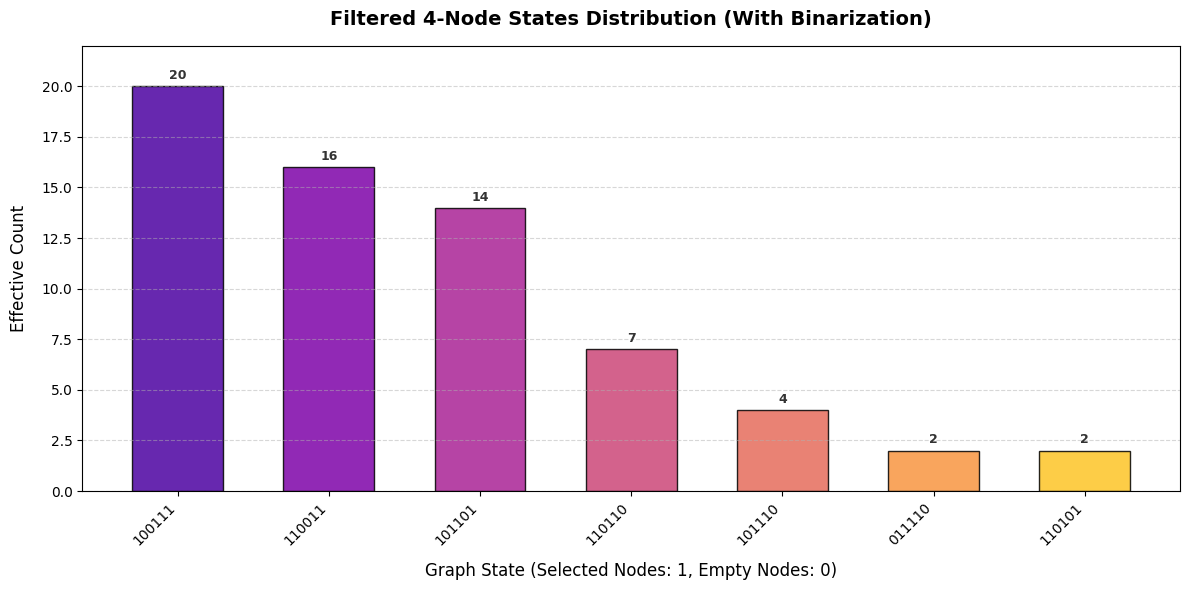

In [71]:
filtered_result = {}

for fock_state_obj, count in result.items():
    # 1. 直接获取底层的光子数列表，例如 [0, 0, 1, 1, 2, 0]
    photon_list = fock_state_obj.state.tolist()
    
    # 2. 过滤掉全 0 的真空态（因为它对寻找子图没有贡献）
    if sum(photon_list) == 0:
        continue
        
    # 3. 【核心步骤】二值化处理：有光子（不管是1个还是2个）就计为 1，没光子计为 0
    # 这样可以完美消除冲突事件带来的负面影响，并恢复它对应的图节点信息
    binary_list = [1 if x > 0 else 0 for x in photon_list]
    
    # 4. 筛选出激活节点数刚好等于 4 的事件（即对应 4 个顶点的子图）
    if sum(binary_list) == 4:
        # 将二值化后的列表转为字符串作为柱状图的横坐标标签，例如 "101101"
        state_label = "".join(map(str, binary_list))
        
        # 累加计数（因为不同的多光子冲突态二值化后可能会合并成同一个图状态）
        filtered_result[state_label] = filtered_result.get(state_label, 0) + count

# 5. 按出现频次（Count）从大到小排序
sorted_filtered = sorted(filtered_result.items(), key=lambda x: x[1], reverse=True)

# 6. 开始绘制美化后的条形图
if sorted_filtered:
    states = [item[0] for item in sorted_filtered]
    counts = [item[1] for item in sorted_filtered]
    
    plt.figure(figsize=(12, 6), dpi=100)
    
    # 使用著名的 plasma 渐变色主题
    colors = sns.color_palette("plasma", len(states))
    
    bars = plt.bar(states, counts, color=colors, edgecolor='black', alpha=0.85, width=0.6)
    
    # 在每个柱子上方标注具体的频次数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + max(counts)*0.01, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')
                 
    # 图表细节美化
    plt.title("Filtered 4-Node States Distribution (With Binarization)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Graph State (Selected Nodes: 1, Empty Nodes: 0)", fontsize=12, labelpad=10)
    plt.ylabel("Effective Count", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 设置纵轴留白，防止顶部文字被框线挡住
    plt.ylim(0, max(counts) * 1.1)
    
    plt.tight_layout()
    plt.show()
else:
    print("二值化后仍未找到包含 4 个有效节点的状态！请检查原始 result 中的最大光子事件分布。")

In [72]:
df1 = df

In [73]:
df = pd.DataFrame(list(formatted_data.items()), columns=['State', 'Count'])
all_states = [format(i, '06b') for i in range(64)]  # 从0到63，格式化为6位二进制
all_df = pd.DataFrame({'State': all_states})
df_complete = all_df.merge(df, on='State', how='left').fillna(0)
df_complete['Count'] = df_complete['Count'].astype(int)
counts = torch.tensor(df_complete['Count'].values, dtype=torch.float32)

In [74]:
counts

tensor([1570.,    0.,    0.,   19.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,  207.,    0.,    0.,    0.,    0.,    0.,   52.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,   14.,    4.,    0.,   14.,    0.,
           0.,    0.,    0.,    0.,    7.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.])

In [75]:
import src.model.utils as utils
import src.model.gbs_attention as gbs_attention

gay = gbs_attention.GBSAttention()
count_gay = gay.gbs(adj_matrix)

print(count_gay)

Using MCMC method to sample the final states!


chain 1:   0%|                                          | 0/408 [00:00<?, ?it/s]

chain 5: 100%|█████████████████████████████| 411/411 [00:00<00:00, 10803.83it/s]


tensor([1.2560e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.1000e+01, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 3.2000e+01, 0.0000e+00, 0.0000e+00,
        3.5000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        9.3000e+01, 0.0000e+00, 0.0000e+00, 6.0000e+00, 0.0000e+00, 0.0000e+00,
        3.6000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.2000e+01, 0.0000e+00,
        8.6000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.5000e+01, 0.0000e+00, 0.0000e+00, 4.0000e+00, 0.0000e+00,
        2.4000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00])


In [76]:
df1

,State,Count
0,000000,1570
1,001100,207
2,010010,52
3,000121,20
4,020002,20
5,000011,19
6,200121,19
7,110022,16
8,101101,14
9,110000,14


In [77]:
all_df

,State
0,000000
1,000001
2,000010
3,000011
4,000100
...,...
59,111011
60,111100
61,111101
62,111110


In [78]:
# ==================== 你原本的代码（保持原样） ====================
df_complete = all_df.merge(df1, on='State', how='left').fillna(0)
df_complete['Count'] = df_complete['Count'].astype(int)
counts = torch.tensor(df_complete['Count'].values, dtype=torch.float32)

# ==================== 改造部分 ====================

# 1. 将 64 个二进制字符串转换为形状为 (64, 6) 的二值矩阵 (Tensor)
# 'all_states' 里的每个元素如 '101100' 转换为 [1, 0, 1, 1, 0, 0]
state_matrix = torch.tensor(
    [[int(bit) for bit in state] for state in all_df['State']], 
    dtype=torch.float32
)

# 2. 计算每个状态的概率 (对应你说的 1/1024, 3/1024)
# 这里假设总数是 1024，如果是动态总数可以换成 counts.sum()
total_count = 1024.0
probs = counts / total_count

# 3. 利用矩阵乘法一键生成图的邻接矩阵
# state_matrix.T 的形状是 (6, 64)，probs.diag() 是 (64, 64)，state_matrix 是 (64, 6)
# 相乘后的形状刚好是 (6, 6)，即两两节点同时出现的概率和
adj_matrix = torch.matmul(state_matrix.T, torch.matmul(probs.diag(), state_matrix))

# 4. 移除自环权重（即节点自己和自己连线的部分，如果你需要的话）
adj_matrix.fill_diagonal_(0)

adj_matrix

tensor([[0.0000, 0.0205, 0.0176, 0.0244, 0.0107, 0.0137],
        [0.0205, 0.0000, 0.0000, 0.0068, 0.0576, 0.0000],
        [0.0176, 0.0000, 0.0000, 0.2197, 0.0039, 0.0137],
        [0.0244, 0.0068, 0.2197, 0.0000, 0.0107, 0.0137],
        [0.0107, 0.0576, 0.0039, 0.0107, 0.0000, 0.0186],
        [0.0137, 0.0000, 0.0137, 0.0137, 0.0186, 0.0000]])

In [79]:
# ==================== 你原本的代码（保持原样） ====================
counts = torch.tensor(df1['Count'].values, dtype=torch.float32)

# ==================== 改造部分 ====================

# 1. 将 64 个二进制字符串转换为形状为 (64, 6) 的二值矩阵 (Tensor)
# 'all_states' 里的每个元素如 '101100' 转换为 [1, 0, 1, 1, 0, 0]
state_matrix = torch.tensor(
    [[int(bit) for bit in state] for state in df1['State']], 
    dtype=torch.float32
)

# 2. 计算每个状态的概率 (对应你说的 1/1024, 3/1024)
# 这里假设总数是 1024，如果是动态总数可以换成 counts.sum()
total_count = 1024.0
probs = counts / total_count

# 3. 利用矩阵乘法一键生成图的邻接矩阵
# state_matrix.T 的形状是 (6, 64)，probs.diag() 是 (64, 64)，state_matrix 是 (64, 6)
# 相乘后的形状刚好是 (6, 6)，即两两节点同时出现的概率和
adj_matrix = torch.matmul(state_matrix.T, torch.matmul(probs.diag(), state_matrix))

# 4. 移除自环权重（即节点自己和自己连线的部分，如果你需要的话）
adj_matrix.fill_diagonal_(0)

adj_matrix

tensor([[0.0000, 0.0605, 0.0293, 0.0771, 0.1377, 0.1445],
        [0.0605, 0.0000, 0.0488, 0.0420, 0.1279, 0.2051],
        [0.0293, 0.0488, 0.0000, 0.2393, 0.0459, 0.1113],
        [0.0771, 0.0420, 0.2393, 0.0000, 0.1182, 0.0986],
        [0.1377, 0.1279, 0.0459, 0.1182, 0.0000, 0.2617],
        [0.1445, 0.2051, 0.1113, 0.0986, 0.2617, 0.0000]])

In [4]:
import random
import numpy as np
from itertools import combinations
from functools import lru_cache
import time

def generate_random_matrix(n, symmetric=True, integer=True, min_val=-5, max_val=5):
    """
    生成随机矩阵
    
    参数:
    n: 矩阵大小
    symmetric: 是否对称矩阵
    integer: 是否整数矩阵
    min_val: 最小值
    max_val: 最大值
    """
    if integer:
        matrix = [[random.randint(min_val, max_val) for _ in range(n)] for _ in range(n)]
    else:
        matrix = [[random.uniform(min_val, max_val) for _ in range(n)] for _ in range(n)]
    
    if symmetric:
        for i in range(n):
            for j in range(i+1, n):
                matrix[j][i] = matrix[i][j]
    
    return matrix

def hafnian_bruteforce(matrix):
    """
    使用暴力枚举计算Hafnian (仅适用于小矩阵)
    Hafnian = sum over perfect matchings ∏ M[i][j]
    """
    n = len(matrix)
    if n % 2 != 0:
        return 0.0
    
    # 所有顶点的集合
    vertices = list(range(n))
    
    def recursive_match(remaining, current_product):
        if not remaining:
            return current_product
        
        # 取最小的顶点
        i = remaining[0]
        rest = remaining[1:]
        total = 0
        
        for idx, j in enumerate(rest):
            new_remaining = rest[:idx] + rest[idx+1:]
            total += recursive_match(new_remaining, current_product * matrix[i][j])
        
        return total
    
    result = recursive_match(vertices, 1.0)
    return result

def hafnian_recursive(matrix):
    """
    使用递归和记忆化计算Hafnian
    更高效的实现
    """
    n = len(matrix)
    if n % 2 != 0:
        return 0.0
    
    @lru_cache(maxsize=None)
    def haf(tuple_vertices):
        if not tuple_vertices:
            return 1.0
        
        # 取第一个顶点
        i = tuple_vertices[0]
        rest = list(tuple_vertices[1:])
        
        total = 0.0
        for idx, j in enumerate(rest):
            new_rest = tuple(rest[:idx] + rest[idx+1:])
            total += matrix[i][j] * haf(new_rest)
        
        return total
    
    vertices = tuple(range(n))
    return haf(vertices)

def hafnian_ryser(matrix):
    """
    使用Ryser-like公式计算Hafnian
    适用于中等大小的矩阵
    """
    n = len(matrix)
    if n % 2 != 0:
        return 0.0
    
    m = n // 2
    
    # 生成所有大小为m的子集
    total = 0.0
    vertices = list(range(n))
    
    for subset in combinations(vertices, m):
        # 计算补集
        complement = [v for v in vertices if v not in subset]
        
        # 计算子集大小的影响
        product = 1.0
        for i in range(m):
            product *= matrix[subset[i]][complement[i]]
        
        # 求和
        total += product
    
    return total

def print_matrix(matrix, title="矩阵"):
    """打印矩阵"""
    print(f"\n{title}:")
    for row in matrix:
        print("  ".join(f"{val:6.2f}" if isinstance(val, float) else f"{val:4d}" for val in row))

def main():
    # 生成随机矩阵（偶数维）
    n = 16  # 必须是偶数
    print(f"生成 {n}x{n} 随机对称矩阵")
    
    matrix = generate_random_matrix(n, symmetric=True, integer=True, min_val=-3, max_val=3)
    print_matrix(matrix, "随机生成的对称矩阵")
    
    # 计算Hafnian
    print("\n" + "="*50)
    print("计算Hafnian:")
    print("="*50)
    
    # 方法1: 暴力枚举 (仅适用于小矩阵)
    try:
        start_time = time.time()
        result1 = hafnian_bruteforce(matrix)
        elapsed1 = time.time() - start_time
        print(f"\n暴力枚举法: {result1:.4f} (耗时: {elapsed1:.6f}秒)")
    except RecursionError:
        print("\n暴力枚举法: 矩阵太大，递归深度超出")
    
    # 方法2: 递归记忆化
    start_time = time.time()
    result2 = hafnian_recursive(matrix)
    elapsed2 = time.time() - start_time
    print(f"递归记忆化法: {result2:.4f} (耗时: {elapsed2:.6f}秒)")
    
    # 方法3: Ryser-like公式
    try:
        start_time = time.time()
        result3 = hafnian_ryser(matrix)
        elapsed3 = time.time() - start_time
        print(f"Ryser-like公式法: {result3:.4f} (耗时: {elapsed3:.6f}秒)")
    except RecursionError:
        print("Ryser-like公式法: 组合数太大")
    
    # 验证结果是否一致（对于小矩阵）
    if n <= 8:
        print("\n验证: 所有方法结果应一致")
        if 'result1' in locals() and 'result2' in locals():
            print(f"结果匹配: {abs(result1 - result2) < 1e-10}")
    
    # 演示不同矩阵类型的生成
    print("\n" + "="*50)
    print("生成非对称矩阵示例:")
    print("="*50)
    
    asym_matrix = generate_random_matrix(4, symmetric=False, integer=True)
    print_matrix(asym_matrix, "非对称矩阵")
    
    try:
        result_asym = hafnian_recursive(asym_matrix)
        print(f"\n非对称矩阵的Hafnian: {result_asym:.4f}")
    except:
        print("Hafnian只定义在对称矩阵上")

if __name__ == "__main__":
    main()

生成 16x16 随机对称矩阵

随机生成的对称矩阵:
  -2     2     3     0     0     2    -2     3     3     2     3     3     3     3     0     3
   2     2    -1    -1    -1     0     2    -2    -1     2     1     2    -3     3     0     1
   3    -1     2    -2     1    -2     0    -1    -3    -1     1     1     2     1    -2    -2
   0    -1    -2     0     1     0     1    -1     0    -3    -1    -2     2    -2     3     3
   0    -1     1     1     3     1     0     0     3    -1     0    -1     1     3    -1    -3
   2     0    -2     0     1     2     2    -3    -2     1    -2    -3     2    -3     3     1
  -2     2     0     1     0     2    -2    -3     1     1     1    -1     2     2     1    -3
   3    -2    -1    -1     0    -3    -3    -2     1     1     0     2    -2     2     2     0
   3    -1    -3     0     3    -2     1     1     3    -1    -1    -2     2     2     3     2
   2     2    -1    -3    -1     1     1     1    -1     2    -3     1     2    -3    -1    -1
   3     1     1    -1